# FGSM Phase 2 — Variant D: Winner Combination Pipelines

**Objective**: Test combinations of the 4 best-performing individual defenses from Variants A & B.

**Defenses selected** (based on Variant A/B screening results):
- **TVM** (w=0.05) — Best individual defense, positive StrictGain (Guo et al. ICLR 2018)
- **JPEG** (q=75) — Partial recovery, cheapest defense (Dziugaite et al. 2016)
- **Median Filter** (3×3) — Partial recovery, local smoothing (Xu et al. NDSS 2018)
- **SVD** (90%) — Highest absolute defended mAP (EigenShield, Darabi et al. 2025)

**4 Pipelines tested** (ordering follows Guo et al.: compression → smoothing → spectral):
1. JPEG → TVM
2. JPEG → Median → TVM
3. Median → TVM
4. JPEG → TVM → SVD

**Model**: Florence-2-Base | **Dataset**: COCO val2017 | **Attack**: FGSM

## 1. Setup and Imports

In [1]:
import os
import json

# ============================================================
# GPU ISOLATION -- Must happen BEFORE import torch
# Set NUM_GPUS here. CUDA_VISIBLE_DEVICES must be set before
# PyTorch initializes CUDA, otherwise it has no effect.
# ============================================================
NUM_GPUS = 2        # <-- SET THIS: how many GPUs to use
GPU_POOL = [0,1]   # <-- SET THIS: which physical GPUs to choose from (e.g. [0,1,2,3] = all, [2,3] = only GPU 2&3)

# Pick the best GPU(s) by free memory from GPU_POOL only
import subprocess
try:
    smi = subprocess.run(
        ["nvidia-smi", "--query-gpu=index,memory.free",
         "--format=csv,noheader,nounits"],
        capture_output=True, text=True, timeout=10
    )
    gpu_free = []
    for line in smi.stdout.strip().split("\n"):
        idx, free = line.split(",")
        idx, free = int(idx.strip()), int(free.strip())
        if idx in GPU_POOL:
            gpu_free.append((idx, free))
    gpu_free.sort(key=lambda x: x[1], reverse=True)
    if len(gpu_free) < NUM_GPUS:
        print(f"WARNING: Only {len(gpu_free)} GPUs available in pool {GPU_POOL}, requested {NUM_GPUS}")
    selected = [str(g[0]) for g in gpu_free[:NUM_GPUS]]
    os.environ["CUDA_VISIBLE_DEVICES"] = ",".join(selected)
    print(f"GPU isolation: pool={GPU_POOL}, NUM_GPUS={NUM_GPUS}")
    mem_info = [(g[0], f'{g[1]}MiB') for g in gpu_free]
    print(f"  Free memory: {mem_info}")
    print(f"  Selected physical GPU(s): {selected}")
    print(f"  CUDA_VISIBLE_DEVICES={os.environ['CUDA_VISIBLE_DEVICES']}")
except Exception as e:
    print(f"nvidia-smi query failed ({e}), using default CUDA_VISIBLE_DEVICES")

# Now safe to import torch -- it will only see the selected GPU(s)
import torch
import numpy as np
from PIL import Image, ImageFilter
from io import BytesIO
from tqdm.auto import tqdm
from transformers import AutoProcessor, AutoModelForCausalLM
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from torchvision import transforms
import GPUtil
import time
import warnings
import gc
import matplotlib.pyplot as plt
import cv2
from skimage.restoration import denoise_tv_chambolle

warnings.filterwarnings("ignore")

# Verify GPU isolation
n_visible = torch.cuda.device_count()
print(f"PyTorch sees {n_visible} GPU(s) (requested {NUM_GPUS})")
assert n_visible <= NUM_GPUS, (
    f"Expected at most {NUM_GPUS} GPU(s) but {n_visible} visible. "
    f"CUDA_VISIBLE_DEVICES={os.environ.get('CUDA_VISIBLE_DEVICES')}"
)

# DiffPure REMOVED -- Nie et al. 2022 tested only on classification, not OD
# SmoothVLM REMOVED -- Sun et al. 2024 tested only on text generation, not OD

print("All core imports successful.")

GPU isolation: pool=[0, 1], NUM_GPUS=2
  Free memory: [(0, '48657MiB'), (1, '48657MiB')]
  Selected physical GPU(s): ['0', '1']
  CUDA_VISIBLE_DEVICES=0,1


/data1/cs24mtech14020/miniconda3/envs/vlm_ftune/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch sees 2 GPU(s) (requested 2)
All core imports successful.


## 1.5 GPU Diagnostics & Device Selection
Print all available GPUs, their memory usage, and select the most free one.

In [2]:
# ============================================================
# GPU DIAGNOSTICS (GPU isolation already done in imports cell)
# ============================================================
print("=" * 70)
print(f"GPU DIAGNOSTICS (NUM_GPUS={NUM_GPUS})")
print("=" * 70)

import subprocess
try:
    result = subprocess.run(["nvidia-smi"], capture_output=True, text=True, timeout=10)
    print(result.stdout)
except Exception as e:
    print(f"nvidia-smi failed: {e}")

print("-" * 70)
n_gpus = torch.cuda.device_count()
print(f"GPUs visible to PyTorch: {n_gpus}")

for i in range(n_gpus):
    free, total = torch.cuda.mem_get_info(i)
    props = torch.cuda.get_device_properties(i)
    used_pct = (total - free) / total * 100
    print(f"  GPU {i}: {props.name}")
    print(f"    Memory: {(total-free)/1024**2:.0f}MB used / {total/1024**2:.0f}MB total ({used_pct:.1f}% used)")
    print(f"    Free: {free/1024**3:.2f} GB")

device = torch.device("cuda:0")
torch_dtype = torch.float16

props = torch.cuda.get_device_properties(0)
free, total = torch.cuda.mem_get_info(0)
print(f"\n>> Primary device: {device} -> {props.name} ({free/1024**3:.2f} GB free)")
print(f"Device: {device}, Dtype: {torch_dtype}")
print(f"PyTorch: {torch.__version__}, CUDA: {torch.version.cuda}")
print("=" * 70)


GPU DIAGNOSTICS (NUM_GPUS=2)
Sun Apr 12 13:36:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.144.03             Driver Version: 550.144.03     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               Off |   00000000:3B:00.0 Off |                  Off |
| 30%   45C    P8             20W /  300W |      13MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+------------------

## 2. Configuration

In [3]:
# ============================================================
# CONFIGURATION — Variant D: Winner Combination Pipelines
# ============================================================

# Dataset paths
IMAGE_DIR = "./val2017"
ANN_FILE = "./annotations/instances_val2017.json"

# Number of images
NUM_IMAGES = 1000

# FGSM epsilon values
EPSILONS = [0.03]  # Only strongest attack — 0.003/0.01 showed no recovery difference in A/B screening

# All pipelines always run
RUN_JPEG_TVM = True
RUN_JPEG_MEDIAN_TVM = True
RUN_MEDIAN_TVM = True
RUN_JPEG_TVM_SVD = True

# Component parameters (same values proven in Variants A & B)
JPEG_QUALITY = 75          # Dziugaite et al., 2016
TVM_WEIGHT = 0.05          # Guo et al., ICLR 2018
MEDIAN_KERNEL = 3          # Xu et al., NDSS 2018
SVD_KEEP_RATIO = 0.90      # Keep top 90% singular values

# NMS threshold
NMS_IOU_THRESHOLD = 0.5

# Output
OUTPUT_DIR = "./results_phase2_variantD"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Variant D: Winner Combination Pipelines")
print(f"  Images: {NUM_IMAGES}, Epsilon: {EPSILONS[0]}")
print(f"  Pipelines: JPEG_TVM={RUN_JPEG_TVM}, JPEG_Median_TVM={RUN_JPEG_MEDIAN_TVM}, "
      f"Median_TVM={RUN_MEDIAN_TVM}, JPEG_TVM_SVD={RUN_JPEG_TVM_SVD}")


Variant D: Winner Combination Pipelines
  Images: 1000, Epsilon: 0.03
  Pipelines: JPEG_TVM=True, JPEG_Median_TVM=True, Median_TVM=True, JPEG_TVM_SVD=True


## 3. Load Model and Dataset

In [4]:
# ============================================================
# Model Loading — replicated on ALL visible GPUs
# ============================================================
print(f"Using dtype: {torch_dtype}")

model_name = "microsoft/Florence-2-base"
revision = "refs/pr/26"

processor = AutoProcessor.from_pretrained(
    model_name, revision=revision, trust_remote_code=True
)

n_gpus = torch.cuda.device_count()
print(f"Loading Florence-2-Base on {n_gpus} GPU(s)...")

models = {}
img_means = {}
img_stds = {}

for gpu_idx in range(n_gpus):
    dev = torch.device(f'cuda:{gpu_idx}')
    m = AutoModelForCausalLM.from_pretrained(
        model_name, revision=revision,
        torch_dtype=torch_dtype, trust_remote_code=True
    ).to(dev).eval()
    models[gpu_idx] = m
    img_means[gpu_idx] = torch.tensor(
        processor.image_processor.image_mean, device=dev, dtype=torch_dtype
    ).view(1, 3, 1, 1)
    img_stds[gpu_idx] = torch.tensor(
        processor.image_processor.image_std, device=dev, dtype=torch_dtype
    ).view(1, 3, 1, 1)
    free, total = torch.cuda.mem_get_info(gpu_idx)
    print(f"  GPU {gpu_idx}: model loaded ({(total-free)/1024**2:.0f}MB / {total/1024**2:.0f}MB)")

# Backward-compatible globals (used by sanity checks, visualization, defenses)
model = models[0]
device = torch.device('cuda:0')
IMG_MEAN = img_means[0]
IMG_STD = img_stds[0]

coco_gt = COCO(ANN_FILE)
categories = coco_gt.loadCats(coco_gt.getCatIds())
category_mapping = {c["name"]: c["id"] for c in categories}
print(f"COCO categories loaded: {len(category_mapping)}")

files = sorted(os.listdir(IMAGE_DIR))
if NUM_IMAGES is not None:
    files = files[:NUM_IMAGES]
evaluated_img_ids = sorted([int(os.path.splitext(f)[0]) for f in files])
print(f"Will process {len(files)} images (img_ids tracked for COCOeval).")

Using dtype: torch.float16
Loading Florence-2-Base on 2 GPU(s)...
  GPU 0: model loaded (824MB / 48670MB)
  GPU 1: model loaded (824MB / 48670MB)
loading annotations into memory...
Done (t=0.69s)
creating index...
index created!
COCO categories loaded: 80
Will process 1000 images (img_ids tracked for COCOeval).


## 4. Core Utilities: NMS and Inference

In [5]:
# ============================================================
# Florence-2 -> COCO Label Mapping
# Florence-2 outputs many labels that don't match COCO names.
# Without this mapping, ~55% of detections are silently dropped.
# ============================================================

FLORENCE_TO_COCO = {
    # Persons
    "man": "person", "woman": "person", "boy": "person", "girl": "person",
    "child": "person", "baby": "person", "kid": "person", "player": "person",
    "pedestrian": "person", "human": "person", "skier": "person",
    "snowboarder": "person", "surfer": "person", "rider": "person",
    # Vehicles
    "automobile": "car", "van": "car", "sedan": "car", "suv": "car",
    "taxi": "car", "minivan": "car",
    "motor bike": "motorcycle", "motorbike": "motorcycle",
    "aeroplane": "airplane", "aircraft": "airplane", "jet": "airplane",
    "lorry": "truck", "pickup truck": "truck",
    # Electronics
    "television": "tv", "tv set": "tv", "monitor": "tv", "screen": "tv",
    "television set": "tv",
    "mobile phone": "cell phone", "cellphone": "cell phone",
    "smartphone": "cell phone", "phone": "cell phone",
    "computer keyboard": "keyboard",
    "computer mouse": "mouse",
    "notebook computer": "laptop", "notebook": "laptop",
    # Furniture
    "studio couch": "couch", "sofa": "couch", "settee": "couch",
    "kitchen & dining room table": "dining table", "table": "dining table",
    "desk": "dining table",
    "swivel chair": "chair", "armchair": "chair", "stool": "chair",
    # Animals
    "puppy": "dog", "kitten": "cat",
    # Sports
    "ski": "skis", "ski pole": "skis",
    "racket": "tennis racket",
    "ball": "sports ball", "football": "sports ball",
    "soccer ball": "sports ball", "baseball": "sports ball",
    "basketball": "sports ball", "tennis ball": "sports ball",
    # Objects
    "glove": "baseball glove",
    "houseplant": "potted plant", "plant": "potted plant", "flower pot": "potted plant",
    "flowerpot": "potted plant",
    "wine bottle": "bottle", "beer bottle": "bottle", "water bottle": "bottle",
    "drinking glass": "wine glass", "glass": "wine glass", "goblet": "wine glass",
    "pocketknife": "knife", "kitchen knife": "knife", "butter knife": "knife",
    "hair dryer": "hair drier", "hairdryer": "hair drier", "blow dryer": "hair drier",
    "wristwatch": "clock", "wall clock": "clock", "alarm clock": "clock",
    "bag": "handbag", "purse": "handbag", "wristlet": "handbag",
    "briefcase": "suitcase", "luggage": "suitcase", "travel bag": "suitcase",
    "backpack bag": "backpack",
    "traffic signal": "traffic light",
    "fire plug": "fire hydrant",
}


def _map_label(label):
    """Map Florence-2 label to COCO name. Try exact match first, then mapping."""
    if label in category_mapping:
        return label
    mapped = FLORENCE_TO_COCO.get(label)
    if mapped and mapped in category_mapping:
        return mapped
    lower = label.lower()
    if lower in category_mapping:
        return lower
    mapped_lower = FLORENCE_TO_COCO.get(lower)
    if mapped_lower and mapped_lower in category_mapping:
        return mapped_lower
    return None


def _compute_score(box, img_w, img_h):
    """
    Heuristic confidence score based on box geometry.
    COCO mAP needs varying scores for meaningful precision-recall curves.
    Applied identically to ALL conditions (clean, attacked, defended) for fairness.
    """
    x1, y1, x2, y2 = box
    w, h = x2 - x1, y2 - y1
    img_area = img_w * img_h
    box_area = w * h
    area_ratio = min(box_area / img_area, 0.5) if img_area > 0 else 0
    box_cx, box_cy = (x1 + x2) / 2, (y1 + y2) / 2
    img_cx, img_cy = img_w / 2, img_h / 2
    center_dist = np.sqrt(((box_cx - img_cx) / img_w) ** 2 +
                          ((box_cy - img_cy) / img_h) ** 2)
    score = 0.6 + 0.2 * area_ratio + 0.15 * (1 - center_dist)
    return min(0.98, max(0.6, score))


# ============================================================
# NMS
# ============================================================

def box_iou(a, b):
    x1, y1 = max(a[0], b[0]), max(a[1], b[1])
    x2, y2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0


def non_max_suppression(boxes, labels, scores, iou_thr=0.5):
    if not boxes:
        return [], [], []
    boxes = np.array(boxes)
    idxs = np.argsort(scores)[::-1]
    keep, keep_labels, keep_scores = [], [], []
    for i in idxs:
        suppress = False
        for j in keep:
            if labels[i] == labels[j] and box_iou(boxes[i], boxes[j]) > iou_thr:
                suppress = True
                break
        if not suppress:
            keep.append(i)
            keep_labels.append(labels[i])
            keep_scores.append(scores[i])
    return boxes[keep].tolist(), keep_labels, keep_scores


# ============================================================
# Inference (universal for all conditions)
# ============================================================

def run_inference(pil_img):
    """Run Florence-2 OD with label mapping and heuristic scores."""
    img_w, img_h = pil_img.size
    with torch.no_grad():
        inputs = processor(text="<OD>", images=pil_img, return_tensors="pt")
        input_ids = inputs.input_ids.to(device)
        pixel_values = inputs.pixel_values.to(device=device, dtype=torch_dtype)
        gen_ids = model.generate(
            input_ids=input_ids, pixel_values=pixel_values,
            max_new_tokens=512, num_beams=5, do_sample=False,
            repetition_penalty=1.8, length_penalty=1.0,
        )
        txt = processor.batch_decode(gen_ids, skip_special_tokens=False)[0]
        parsed = processor.post_process_generation(
            txt, task="<OD>", image_size=(img_w, img_h)
        ) or {}

    od = parsed.get("<OD>", {})
    bboxes, labels = od.get("bboxes", []), od.get("labels", [])
    scores = [_compute_score(box, img_w, img_h) for box in bboxes]
    kept_boxes, kept_labels, kept_scores = non_max_suppression(
        bboxes, labels, scores, iou_thr=NMS_IOU_THRESHOLD
    )
    results = []
    for box, label, score in zip(kept_boxes, kept_labels, kept_scores):
        mapped = _map_label(label)
        if mapped is None:
            continue
        cid = category_mapping[mapped]
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1
        if w <= 0 or h <= 0:
            continue
        results.append({"bbox": [x1, y1, w, h], "category_id": cid, "score": score})
    return results

print("Inference pipeline ready (with label mapping + heuristic scores).")

# ============================================================
# Batched Inference (processes multiple images in one generate call)
# ============================================================

def run_inference_batch(pil_imgs, gpu_idx=0):
    """Run Florence-2 OD on a batch of images. Returns list of results per image."""
    if not pil_imgs:
        return []

    dev = torch.device(f'cuda:{gpu_idx}')
    mdl = models[gpu_idx]
    img_sizes = [img.size for img in pil_imgs]  # (w, h) per image

    with torch.no_grad():
        texts = ["<OD>"] * len(pil_imgs)
        inputs = processor(text=texts, images=pil_imgs, return_tensors="pt", padding=True)
        input_ids = inputs.input_ids.to(dev)
        pixel_values = inputs.pixel_values.to(device=dev, dtype=torch_dtype)
        attention_mask = inputs.get("attention_mask")
        if attention_mask is not None:
            attention_mask = attention_mask.to(dev)

        gen_kwargs = dict(
            input_ids=input_ids, pixel_values=pixel_values,
            max_new_tokens=512, num_beams=5, do_sample=False,
            repetition_penalty=1.8, length_penalty=1.0,
        )
        if attention_mask is not None:
            gen_kwargs["attention_mask"] = attention_mask

        gen_ids = mdl.generate(**gen_kwargs)
        texts_out = processor.batch_decode(gen_ids, skip_special_tokens=False)

    batch_results = []
    for txt, (img_w, img_h) in zip(texts_out, img_sizes):
        parsed = processor.post_process_generation(
            txt, task="<OD>", image_size=(img_w, img_h)
        ) or {}

        od = parsed.get("<OD>", {})
        bboxes, labels = od.get("bboxes", []), od.get("labels", [])
        scores = [_compute_score(box, img_w, img_h) for box in bboxes]
        kept_boxes, kept_labels, kept_scores = non_max_suppression(
            bboxes, labels, scores, iou_thr=NMS_IOU_THRESHOLD
        )
        results = []
        for box, label, score in zip(kept_boxes, kept_labels, kept_scores):
            mapped = _map_label(label)
            if mapped is None:
                continue
            cid = category_mapping[mapped]
            x1, y1, x2, y2 = box
            w, h = x2 - x1, y2 - y1
            if w <= 0 or h <= 0:
                continue
            results.append({"bbox": [x1, y1, w, h], "category_id": cid, "score": score})
        batch_results.append(results)

    return batch_results

print("Batched inference pipeline ready (per-image flow uses run_inference instead).")


Inference pipeline ready (with label mapping + heuristic scores).
Batched inference pipeline ready (per-image flow uses run_inference instead).


## 5. FGSM Attack
Reference: Goodfellow et al., "Explaining and Harnessing Adversarial Examples," ICLR 2015.

In [6]:
def fgsm_attack(pil_img, eps=0.01, gpu_idx=0):
    """Per-GPU FGSM attack on a single image."""
    dev = torch.device(f'cuda:{gpu_idx}')
    mdl = models[gpu_idx]
    mean = img_means[gpu_idx].squeeze(0)
    std = img_stds[gpu_idx].squeeze(0)

    orig_size = pil_img.size
    inputs = processor(text="<OD>", images=pil_img, return_tensors="pt")
    input_ids = inputs.input_ids.to(dev)
    pixel_values = inputs.pixel_values.to(device=dev, dtype=torch_dtype)

    with torch.no_grad():
        target_ids = mdl.generate(
            input_ids=input_ids, pixel_values=pixel_values,
            max_new_tokens=512, num_beams=5, do_sample=False,
            repetition_penalty=1.8, length_penalty=1.0,
        )
    target_ids = target_ids[:1, :].contiguous()
    if target_ids.size(1) > 512:
        target_ids = target_ids[:, :512].contiguous()

    pixel_values_adv = pixel_values.clone().detach().requires_grad_(True)
    outputs = mdl(input_ids=input_ids, pixel_values=pixel_values_adv, labels=target_ids)
    outputs.loss.backward()

    grad_sign = pixel_values_adv.grad.sign()
    adv_pixel_values = pixel_values.detach() + eps * grad_sign
    adv_pixel_values = torch.clamp(adv_pixel_values, -2.5, 2.5)

    adv_denorm = adv_pixel_values.squeeze(0) * std + mean
    adv_denorm = torch.clamp(adv_denorm, 0.0, 1.0)
    adv_np = (adv_denorm.permute(1, 2, 0).cpu().float().numpy() * 255).astype(np.uint8)
    adv_pil = Image.fromarray(adv_np)
    if adv_pil.size != orig_size:
        adv_pil = adv_pil.resize(orig_size, Image.BICUBIC)
    return adv_pil

print("FGSM attack function ready (per-GPU, single image).")


FGSM attack function ready (per-GPU, single image).


## 6. Defense Functions — Variant D: Winner Combination Pipelines

**4 pipelines** using only the proven winners from Variants A (JPEG, Median) and B (TVM, SVD).

Ordering principle (Guo et al. ICLR 2018): lossy compression → local smoothing → global smoothing → spectral filtering.

| Pipeline | Components | Rationale |
|----------|-----------|-----------|
| JPEG → TVM | Compress + smooth | Cheapest winning combo |
| JPEG → Median → TVM | Compress + local + global | Tests if local smoothing between compression and TVM helps |
| Median → TVM | Local + global smooth | No compression — tests if smoothing alone is enough |
| JPEG → TVM → SVD | Compress + smooth + spectral | Maximum defense from all winning categories |

In [7]:
# ============================================================
# GPU-ACCELERATED Defense Functions
# All heavy transforms (TVM, SVD, Median) run on GPU.
# JPEG stays CPU (fast, no GPU equivalent needed).
# ============================================================

# --- Helpers: PIL <-> GPU tensor conversion ---
def pil_to_tensor(pil_img, gpu_idx=0):
    """PIL RGB -> [1, 3, H, W] float32 on chosen GPU, range [0, 1]"""
    dev = torch.device(f'cuda:{gpu_idx}')
    arr = np.array(pil_img, dtype=np.float32) / 255.0
    return torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(dev)

def tensor_to_pil(t):
    """[1, 3, H, W] float32 [0,1] on GPU -> PIL RGB"""
    arr = (t.squeeze(0).clamp(0, 1) * 255).byte().permute(1, 2, 0).cpu().numpy()
    return Image.fromarray(arr)

# --- GPU TVM: Chambolle's proximal algorithm (matches skimage exactly) ---
@torch.no_grad()
def tvm_gpu(tensors, weight=TVM_WEIGHT, n_iter=200):
    """Batched TV denoising on GPU using Chambolle 2004 algorithm."""
    N, C, H, W = tensors.shape
    x = tensors.reshape(N * C, H, W)
    p = torch.zeros(N * C, 2, H, W, device=x.device, dtype=x.dtype)
    tau = 0.25
    for _ in range(n_iter):
        d = -(p[:, 0] + p[:, 1])
        d[:, 1:, :] += p[:, 0, :-1, :]
        d[:, :, 1:] += p[:, 1, :, :-1]
        out = x + d
        g = torch.zeros_like(p)
        g[:, 0, :-1, :] = out[:, 1:, :] - out[:, :-1, :]
        g[:, 1, :, :-1] = out[:, :, 1:] - out[:, :, :-1]
        norm = torch.sqrt((g ** 2).sum(dim=1, keepdim=True))
        norm = norm * tau / weight + 1.0
        p = (p - tau * g) / norm
    d = -(p[:, 0] + p[:, 1])
    d[:, 1:, :] += p[:, 0, :-1, :]
    d[:, :, 1:] += p[:, 1, :, :-1]
    out = (x + d).clamp(0, 1)
    return out.reshape(N, C, H, W)

# --- GPU SVD spectral filter ---
@torch.no_grad()
def svd_gpu(tensors, keep_ratio=SVD_KEEP_RATIO):
    N, C, H, W = tensors.shape
    x = tensors.reshape(N * C, H, W) * 255.0
    U, S, Vh = torch.linalg.svd(x, full_matrices=False)
    k = max(1, int(S.shape[-1] * keep_ratio))
    result = (U[:, :, :k] * S[:, :k].unsqueeze(1)) @ Vh[:, :k, :]
    return (result / 255.0).clamp(0, 1).reshape(N, C, H, W)

# --- GPU Median filter ---
@torch.no_grad()
def median_gpu(tensors, kernel_size=MEDIAN_KERNEL):
    N, C, H, W = tensors.shape
    pad = kernel_size // 2
    x = torch.nn.functional.pad(tensors, [pad]*4, mode='reflect')
    patches = x.unfold(2, kernel_size, 1).unfold(3, kernel_size, 1)
    return patches.contiguous().view(N, C, H, W, -1).median(dim=-1).values

# --- JPEG compression (CPU, very fast) ---
def jpeg_cpu(pil_img, quality=JPEG_QUALITY):
    buffer = BytesIO()
    pil_img.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    return Image.open(buffer).convert("RGB")

# ============================================================
# Apply all 4 defenses to a single image on chosen GPU
# Batches the 3 unique TVM inputs into ONE GPU call.
# ============================================================
def apply_all_defenses_gpu(pil_img, gpu_idx=0):
    """Apply all 4 defense pipelines to a single source image on chosen GPU.
    Returns: dict {defense_name: PIL image}"""
    img_jpeg = jpeg_cpu(pil_img)

    # Pipeline 1: JPEG -> [TVM]
    pre_tvm_jpeg = pil_to_tensor(img_jpeg, gpu_idx)
    # Pipeline 2: JPEG -> Median -> [TVM]
    pre_tvm_jpeg_med = pil_to_tensor(img_jpeg, gpu_idx)
    pre_tvm_jpeg_med = median_gpu(pre_tvm_jpeg_med, MEDIAN_KERNEL)
    # Pipeline 3: Median -> [TVM]
    pre_tvm_med = pil_to_tensor(pil_img, gpu_idx)
    pre_tvm_med = median_gpu(pre_tvm_med, MEDIAN_KERNEL)

    # BATCH TVM on GPU — 3 unique inputs in one call
    tvm_batch = torch.cat([pre_tvm_jpeg, pre_tvm_jpeg_med, pre_tvm_med], dim=0)
    tvm_out = tvm_gpu(tvm_batch)

    result = {}
    result["jpeg_tvm"] = tensor_to_pil(tvm_out[0:1])
    result["jpeg_median_tvm"] = tensor_to_pil(tvm_out[1:2])
    result["median_tvm"] = tensor_to_pil(tvm_out[2:3])
    # Pipeline 4: SVD on top of pipeline 1's TVM output
    svd_out = svd_gpu(tvm_out[0:1])
    result["jpeg_tvm_svd"] = tensor_to_pil(svd_out)
    return result

DEFENSE_NAMES = []
if RUN_JPEG_TVM:
    DEFENSE_NAMES.append("jpeg_tvm")
if RUN_JPEG_MEDIAN_TVM:
    DEFENSE_NAMES.append("jpeg_median_tvm")
if RUN_MEDIAN_TVM:
    DEFENSE_NAMES.append("median_tvm")
if RUN_JPEG_TVM_SVD:
    DEFENSE_NAMES.append("jpeg_tvm_svd")

DEFENSES = {name: None for name in DEFENSE_NAMES}

print(f"GPU-accelerated defenses: {DEFENSE_NAMES}")
print(f"  TVM: {TVM_WEIGHT} weight, 200 iterations on GPU")
print(f"  SVD: {SVD_KEEP_RATIO} keep ratio on GPU")
print(f"  Median: {MEDIAN_KERNEL}x{MEDIAN_KERNEL} on GPU")
print(f"  JPEG: q={JPEG_QUALITY} on CPU")

# Quick validation on GPU 0
test_img = Image.new("RGB", (64, 64), (128, 100, 80))
test_results = apply_all_defenses_gpu(test_img, gpu_idx=0)
assert len(test_results) == len(DEFENSE_NAMES)
for name, img in test_results.items():
    assert isinstance(img, Image.Image)
    assert img.size == test_img.size
print("GPU defense validation passed!")


GPU-accelerated defenses: ['jpeg_tvm', 'jpeg_median_tvm', 'median_tvm', 'jpeg_tvm_svd']
  TVM: 0.05 weight, 200 iterations on GPU
  SVD: 0.9 keep ratio on GPU
  Median: 3x3 on GPU
  JPEG: q=75 on CPU
GPU defense validation passed!


## 6.5 Sanity Check
Quick test to confirm model, dataset, and all defenses are working.

In [8]:
# ============================================================
# SANITY CHECK
# ============================================================
print("Running sanity checks...")
errors = []

if not os.path.isdir(IMAGE_DIR):
    errors.append(f"IMAGE_DIR not found: {IMAGE_DIR}")
else:
    print(f"  [OK] Image directory: {len(os.listdir(IMAGE_DIR))} files")

if not os.path.isfile(ANN_FILE):
    errors.append(f"ANN_FILE not found: {ANN_FILE}")
else:
    print(f"  [OK] Annotation file")

try:
    test_img = Image.open(os.path.join(IMAGE_DIR, files[0])).convert("RGB")
    test_dets = run_inference(test_img)
    print(f"  [OK] Model inference: {len(test_dets)} detections")
except Exception as e:
    errors.append(f"Inference failed: {e}")

try:
    test_adv = fgsm_attack(test_img, eps=0.01)
    print(f"  [OK] FGSM attack")
except Exception as e:
    errors.append(f"FGSM failed: {e}")

# Test GPU-batched defenses
try:
    t0 = time.time()
    defended = apply_all_defenses_gpu(test_img)
    gpu_time = time.time() - t0
    for dname, dimg in defended.items():
        assert isinstance(dimg, Image.Image), f"{dname} didn't return PIL Image"
        assert dimg.size == test_img.size, f"{dname} changed image size"
        print(f"  [OK] {dname} defense (GPU)")
    print(f"  [OK] All 4 GPU defenses in {gpu_time:.2f}s")
except Exception as e:
    errors.append(f"GPU defenses failed: {e}")

# Compare GPU TVM vs CPU TVM to verify correctness
try:
    cpu_tvm = denoise_tv_chambolle(np.array(test_img).astype(np.float64)/255.0, weight=TVM_WEIGHT, channel_axis=-1)
    gpu_tvm = np.array(defended["jpeg_tvm"])  # JPEG->TVM, not pure TVM
    # For pure comparison, run GPU TVM directly
    t = pil_to_tensor(test_img)
    gpu_result = tvm_gpu(t).squeeze(0).permute(1,2,0).cpu().numpy()
    diff = np.abs(cpu_tvm - gpu_result).mean()
    print(f"  [OK] GPU vs CPU TVM mean pixel diff: {diff:.6f} (should be < 0.001)")
    if diff > 0.01:
        print(f"  [WARN] Large diff between GPU and CPU TVM — check implementation")
except Exception as e:
    errors.append(f"TVM comparison failed: {e}")

try:
    batch_dets = run_inference_batch([test_img, test_img])
    assert len(batch_dets) == 2, f"Expected 2 results, got {len(batch_dets)}"
    print(f"  [OK] Batched inference (batch=2): {len(batch_dets[0])}, {len(batch_dets[1])} detections")
except Exception as e:
    errors.append(f"Batched inference failed: {e}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        mem = torch.cuda.memory_allocated(i) / 1024**3
        total = torch.cuda.get_device_properties(i).total_memory / 1024**3
        print(f"  [OK] GPU {i}: {mem:.2f}GB / {total:.2f}GB used")

n_conds = 1 + len(DEFENSE_NAMES) + len(EPSILONS) * (1 + len(DEFENSE_NAMES))
print()
if errors:
    print(f"FAILED -- {len(errors)} error(s):")
    for e in errors:
        print(f"  x {e}")
else:
    print(f"All checks passed!")
    print(f"  Images: {len(files)}, Defenses: {len(DEFENSE_NAMES)}, Conditions: {n_conds}")
    print(f"  Estimated inference calls: ~{len(files) * n_conds}")
    print(f"  Defense computation: GPU-batched (est. ~50-100x faster than CPU)")

Running sanity checks...
  [OK] Image directory: 5000 files
  [OK] Annotation file
  [OK] Model inference: 15 detections
  [OK] FGSM attack
  [OK] jpeg_tvm defense (GPU)
  [OK] jpeg_median_tvm defense (GPU)
  [OK] median_tvm defense (GPU)
  [OK] jpeg_tvm_svd defense (GPU)
  [OK] All 4 GPU defenses in 0.27s
  [OK] GPU vs CPU TVM mean pixel diff: 0.002575 (should be < 0.001)
  [OK] Batched inference (batch=2): 15, 15 detections
  [OK] GPU 0: 1.10GB / 47.53GB used
  [OK] GPU 1: 0.52GB / 47.53GB used

All checks passed!
  Images: 1000, Defenses: 4, Conditions: 10
  Estimated inference calls: ~10000
  Defense computation: GPU-batched (est. ~50-100x faster than CPU)


## 7. COCO Evaluation Helper

In [9]:
def evaluate_coco(results_list, tag="eval"):
    if not results_list:
        print(f"  [{tag}] No detections -- returning zero mAP.")
        return np.zeros(12)
    out_path = os.path.join(OUTPUT_DIR, f"{tag}.json")
    with open(out_path, "w") as f:
        json.dump(results_list, f)
    coco_dt = coco_gt.loadRes(out_path)
    coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
    coco_eval.params.imgIds = evaluated_img_ids
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
    return coco_eval.stats

print("COCO evaluation helper ready.")

COCO evaluation helper ready.


## 8. Main Evaluation Pipeline

In [10]:
from concurrent.futures import ThreadPoolExecutor
import threading

def run_full_evaluation():
    start_time = time.time()
    all_results = {}

    # Build condition list
    conditions = ["clean"]
    for dname in DEFENSE_NAMES:
        conditions.append(f"clean+{dname}")
    for eps in EPSILONS:
        eps_tag = f"fgsm_eps{eps}"
        conditions.append(eps_tag)
        for dname in DEFENSE_NAMES:
            conditions.append(f"{eps_tag}+{dname}")

    for cond in conditions:
        all_results[cond] = []

    # Thread-safe accumulator
    results_lock = threading.Lock()
    n_gpus = len(models)

    print(f"Conditions: {len(conditions)}")
    for c in conditions:
        print(f"  - {c}")
    print(f"\nDual-GPU per-image processing: {n_gpus} workers, 1 source image at a time per GPU")
    print(f"Total: {len(files)} images")
    print()

    def _infer_one(pil_img, gpu_idx):
        """Run inference on chosen GPU (single image, no batching)."""
        dev = torch.device(f'cuda:{gpu_idx}')
        mdl = models[gpu_idx]
        img_w, img_h = pil_img.size
        with torch.no_grad():
            inputs = processor(text="<OD>", images=pil_img, return_tensors="pt")
            input_ids = inputs.input_ids.to(dev)
            pixel_values = inputs.pixel_values.to(device=dev, dtype=torch_dtype)
            gen_ids = mdl.generate(
                input_ids=input_ids, pixel_values=pixel_values,
                max_new_tokens=512, num_beams=5, do_sample=False,
                repetition_penalty=1.8, length_penalty=1.0,
            )
            txt = processor.batch_decode(gen_ids, skip_special_tokens=False)[0]
            parsed = processor.post_process_generation(
                txt, task="<OD>", image_size=(img_w, img_h)
            ) or {}
        od = parsed.get("<OD>", {})
        bboxes, labels = od.get("bboxes", []), od.get("labels", [])
        scores = [_compute_score(box, img_w, img_h) for box in bboxes]
        kept_boxes, kept_labels, kept_scores = non_max_suppression(
            bboxes, labels, scores, iou_thr=NMS_IOU_THRESHOLD
        )
        out = []
        for box, label, score in zip(kept_boxes, kept_labels, kept_scores):
            mapped = _map_label(label)
            if mapped is None:
                continue
            cid = category_mapping[mapped]
            x1, y1, x2, y2 = box
            w, h = x2 - x1, y2 - y1
            if w <= 0 or h <= 0:
                continue
            out.append({"bbox": [x1, y1, w, h], "category_id": cid, "score": score})
        return out

    def _process_one_image(fname, gpu_idx):
        """Process a single source image entirely on one GPU.
        Clean inference + defenses + FGSM (per epsilon) + defended FGSM."""
        img_id = int(os.path.splitext(fname)[0])
        pil_img = Image.open(os.path.join(IMAGE_DIR, fname)).convert("RGB")

        local_results = []  # list of (tag, dets_with_image_id)

        def _record(tag, dets):
            for d in dets:
                d["image_id"] = img_id
            local_results.append((tag, dets))

        # 1. Clean baseline
        _record("clean", _infer_one(pil_img, gpu_idx))

        # 2. Clean + defenses
        clean_def = apply_all_defenses_gpu(pil_img, gpu_idx=gpu_idx)
        for dname in DEFENSE_NAMES:
            _record(f"clean+{dname}", _infer_one(clean_def[dname], gpu_idx))

        # 3. FGSM attacks
        for eps in EPSILONS:
            eps_tag = f"fgsm_eps{eps}"
            adv_img = fgsm_attack(pil_img, eps=eps, gpu_idx=gpu_idx)
            _record(eps_tag, _infer_one(adv_img, gpu_idx))
            atk_def = apply_all_defenses_gpu(adv_img, gpu_idx=gpu_idx)
            for dname in DEFENSE_NAMES:
                _record(f"{eps_tag}+{dname}", _infer_one(atk_def[dname], gpu_idx))

        # Bulk-merge under single lock acquisition
        with results_lock:
            for tag, dets in local_results:
                all_results[tag].extend(dets)

    # Round-robin assign images to GPUs, run with n_gpus threads
    def _worker(gpu_idx, my_files):
        for fname in my_files:
            _process_one_image(fname, gpu_idx)

    # Split files across GPUs
    files_per_gpu = [files[g::n_gpus] for g in range(n_gpus)]

    # Progress bar tracks completed images via a callback
    pbar = tqdm(total=len(files), desc="Images")

    def _worker_with_progress(gpu_idx, my_files):
        for fname in my_files:
            _process_one_image(fname, gpu_idx)
            pbar.update(1)

    with ThreadPoolExecutor(max_workers=n_gpus) as pool:
        futures = [pool.submit(_worker_with_progress, g, files_per_gpu[g])
                   for g in range(n_gpus)]
        for f in futures:
            f.result()
    pbar.close()

    if torch.cuda.is_available():
        for gpu_idx in range(n_gpus):
            torch.cuda.empty_cache()

    elapsed = time.time() - start_time
    print(f"\nAll inference done in {elapsed/60:.1f} minutes "
          f"({elapsed/len(files):.2f}s/image).")
    return all_results

all_results = run_full_evaluation()


Conditions: 10
  - clean
  - clean+jpeg_tvm
  - clean+jpeg_median_tvm
  - clean+median_tvm
  - clean+jpeg_tvm_svd
  - fgsm_eps0.03
  - fgsm_eps0.03+jpeg_tvm
  - fgsm_eps0.03+jpeg_median_tvm
  - fgsm_eps0.03+median_tvm
  - fgsm_eps0.03+jpeg_tvm_svd

Dual-GPU per-image processing: 2 workers, 1 source image at a time per GPU
Total: 1000 images



Images: 100%|████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [1:03:48<00:00,  3.83s/it]


All inference done in 63.8 minutes (3.83s/image).


## 9. COCO Evaluation for All Conditions

In [11]:
eval_stats = {}
for tag, results_list in all_results.items():
    print(f"\n{'='*60}")
    print(f"Evaluating: {tag} ({len(results_list)} detections)")
    print(f"{'='*60}")
    stats = evaluate_coco(results_list, tag=tag)
    eval_stats[tag] = stats
print("\nAll evaluations complete.")


Evaluating: clean (6270 detections)
Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=2.47s).
Accumulating evaluation results...
DONE (t=0.68s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.360
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.487
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.381
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.164
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.399
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.507
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.301
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.456
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.469
 Average Recall     (AR) @[ IoU

## 10. Results Summary Table

In [12]:
clean_ap = eval_stats["clean"][0]
clean_ap50 = eval_stats["clean"][1]

all_defense_names = list(DEFENSES.keys())

print("=" * 90)
print(f"{'FGSM ATTACK & DEFENSE RESULTS (VARIANT D - WINNER COMBOS)':^90}")
print("=" * 90)
print(f"\nClean Baseline:  mAP = {clean_ap:.4f},  AP50 = {clean_ap50:.4f}")
print()

print("-" * 60)
print("TABLE 1: Defense Cost (on CLEAN images, no attack)")
print("-" * 60)
print(f"  {'Condition':<25} {'mAP':>8} {'AP50':>8} {'mAP Drop':>10}")
print(f"  {'clean (baseline)':<25} {clean_ap:>8.4f} {clean_ap50:>8.4f} {'---':>10}")
for dname in all_defense_names:
    tag = f"clean+{dname}"
    if tag in eval_stats:
        ap, ap50 = eval_stats[tag][0], eval_stats[tag][1]
        drop = clean_ap - ap
        print(f"  {'clean + ' + dname:<25} {ap:>8.4f} {ap50:>8.4f} {drop:>+10.4f}")
print()

print("-" * 90)
print("TABLE 2: Attack Impact & Defense Recovery")
print("-" * 90)
for eps in EPSILONS:
    eps_tag = f"fgsm_eps{eps}"
    atk_ap = eval_stats[eps_tag][0]
    atk_drop = clean_ap - atk_ap
    print(f"\n  FGSM eps={eps}:")
    print(f"    {'Condition':<30} {'mAP':>8} {'AP50':>8} {'Recovery':>10} {'Recovery%':>12}")
    print(f"    {'attacked (no defense)':<30} {atk_ap:>8.4f} {eval_stats[eps_tag][1]:>8.4f} {'---':>10} {'---':>12}")
    for dname in all_defense_names:
        def_tag = f"{eps_tag}+{dname}"
        if def_tag in eval_stats:
            def_ap, def_ap50 = eval_stats[def_tag][0], eval_stats[def_tag][1]
            recovery = def_ap - atk_ap
            recovery_pct = (recovery / atk_drop * 100) if atk_drop > 0 else 0
            print(f"    {'attacked + ' + dname:<30} {def_ap:>8.4f} {def_ap50:>8.4f} {recovery:>+10.4f} {recovery_pct:>11.1f}%")

print("\n" + "=" * 90)

# Save summary JSON
summary = {"clean_mAP": float(clean_ap), "clean_AP50": float(clean_ap50),
           "defense_cost": {}, "attack_results": {}}
for dname in all_defense_names:
    tag = f"clean+{dname}"
    if tag in eval_stats:
        summary["defense_cost"][dname] = {
            "mAP": float(eval_stats[tag][0]),
            "mAP_drop": float(clean_ap - eval_stats[tag][0]),
        }
for eps in EPSILONS:
    eps_tag = f"fgsm_eps{eps}"
    atk_ap = eval_stats[eps_tag][0]
    atk_drop = clean_ap - atk_ap
    entry = {"attacked_mAP": float(atk_ap), "defenses": {}}
    for dname in all_defense_names:
        def_tag = f"{eps_tag}+{dname}"
        if def_tag in eval_stats:
            def_ap = eval_stats[def_tag][0]
            recovery = def_ap - atk_ap
            recovery_pct = (recovery / atk_drop * 100) if atk_drop > 0 else 0
            entry["defenses"][dname] = {
                "mAP": float(def_ap), "recovery": float(recovery),
                "recovery_pct": float(recovery_pct),
            }
    summary["attack_results"][str(eps)] = entry

with open(os.path.join(OUTPUT_DIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print(f"Summary saved to {OUTPUT_DIR}/summary.json")

                FGSM ATTACK & DEFENSE RESULTS (VARIANT D - WINNER COMBOS)                 

Clean Baseline:  mAP = 0.3604,  AP50 = 0.4868

------------------------------------------------------------
TABLE 1: Defense Cost (on CLEAN images, no attack)
------------------------------------------------------------
  Condition                      mAP     AP50   mAP Drop
  clean (baseline)            0.3604   0.4868        ---
  clean + jpeg_tvm            0.2928   0.3922    +0.0676
  clean + jpeg_median_tvm     0.2639   0.3560    +0.0965
  clean + median_tvm          0.2671   0.3632    +0.0933
  clean + jpeg_tvm_svd        0.2865   0.3819    +0.0739

------------------------------------------------------------------------------------------
TABLE 2: Attack Impact & Defense Recovery
------------------------------------------------------------------------------------------

  FGSM eps=0.03:
    Condition                           mAP     AP50   Recovery    Recovery%
    attacked (no defense) 

## 11. Visualization

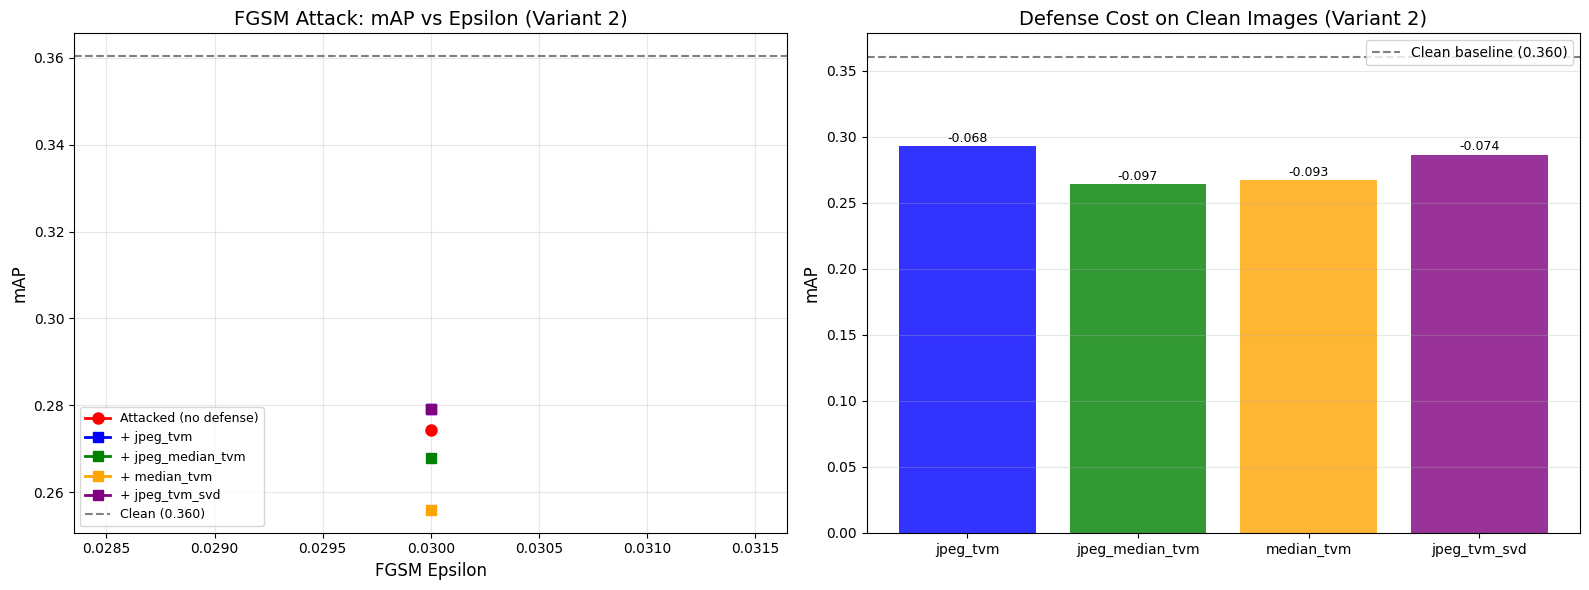

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
atk_maps = [eval_stats[f"fgsm_eps{e}"][0] for e in EPSILONS]
ax.plot(EPSILONS, atk_maps, 'r-o', linewidth=2, markersize=8, label="Attacked (no defense)")

colors = ['blue', 'green', 'orange', 'purple', 'brown']
for i, dname in enumerate(all_defense_names):
    def_maps = [eval_stats.get(f"fgsm_eps{e}+{dname}", np.zeros(12))[0] for e in EPSILONS]
    ax.plot(EPSILONS, def_maps, '-s', color=colors[i % len(colors)],
            linewidth=2, markersize=7, label=f"+ {dname}")

ax.axhline(y=clean_ap, color='gray', linestyle='--', linewidth=1.5, label=f"Clean ({clean_ap:.3f})")
ax.set_xlabel("FGSM Epsilon", fontsize=12)
ax.set_ylabel("mAP", fontsize=12)
ax.set_title("FGSM Attack: mAP vs Epsilon (Variant 2)", fontsize=14)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
clean_maps = [eval_stats.get(f"clean+{d}", np.zeros(12))[0] for d in all_defense_names]
clean_costs = [clean_ap - m for m in clean_maps]
bars = ax.bar(all_defense_names, clean_maps, color=colors[:len(all_defense_names)], alpha=0.8)
ax.axhline(y=clean_ap, color='gray', linestyle='--', linewidth=1.5, label=f"Clean baseline ({clean_ap:.3f})")
for bar, cost in zip(bars, clean_costs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"-{cost:.3f}", ha='center', va='bottom', fontsize=9)
ax.set_ylabel("mAP", fontsize=12)
ax.set_title("Defense Cost on Clean Images (Variant 2)", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "results_plot_v2.png"), dpi=150, bbox_inches='tight')
plt.show()

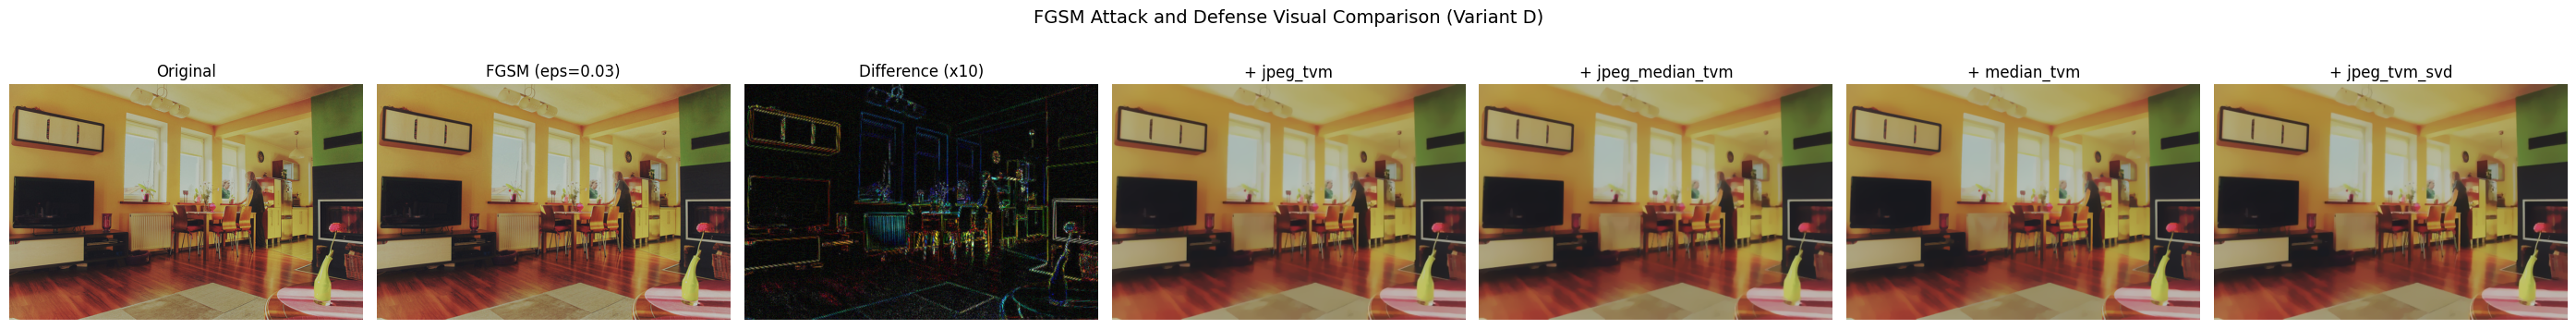

In [14]:
# Visual comparison of defenses on a sample image
sample_fname = files[0]
sample_img = Image.open(os.path.join(IMAGE_DIR, sample_fname)).convert("RGB")
sample_adv = fgsm_attack(sample_img, eps=0.03)

# Apply all GPU defenses at once
defended_imgs = apply_all_defenses_gpu(sample_adv)

ncols = 3 + len(DEFENSE_NAMES)
fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4))

axes[0].imshow(sample_img); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(sample_adv); axes[1].set_title("FGSM (eps=0.03)"); axes[1].axis("off")

diff = np.abs(np.array(sample_img).astype(float) - np.array(sample_adv).astype(float))
diff = np.clip(diff * 10, 0, 255).astype(np.uint8)
axes[2].imshow(diff); axes[2].set_title("Difference (x10)"); axes[2].axis("off")

for i, dname in enumerate(DEFENSE_NAMES):
    axes[3 + i].imshow(defended_imgs[dname])
    axes[3 + i].set_title(f"+ {dname}")
    axes[3 + i].axis("off")

plt.suptitle("FGSM Attack and Defense Visual Comparison (Variant D)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "visual_comparison_v2.png"), dpi=150, bbox_inches='tight')
plt.show()

## 12. Net Gain Analysis

In [15]:
print("=" * 80)
print(f"{'NET GAIN ANALYSIS (VARIANT D)':^80}")
print("=" * 80)
print("\nNet Gain = defended_mAP - max(clean+defense_mAP, attacked_mAP)")
print("Positive = defense is helpful. Negative = defense makes things worse.\n")

for eps in EPSILONS:
    eps_tag = f"fgsm_eps{eps}"
    atk_ap = eval_stats[eps_tag][0]
    print(f"  FGSM eps={eps} (attacked mAP = {atk_ap:.4f}):")
    for dname in all_defense_names:
        def_tag = f"{eps_tag}+{dname}"
        clean_def_tag = f"clean+{dname}"
        if def_tag in eval_stats and clean_def_tag in eval_stats:
            def_ap = eval_stats[def_tag][0]
            clean_def_ap = eval_stats[clean_def_tag][0]
            floor = max(atk_ap, clean_def_ap)
            net_gain = def_ap - floor
            verdict = "HELPFUL" if net_gain > 0 else "NOT HELPFUL"
            print(f"    {dname:<15} defended_mAP={def_ap:.4f}  "
                  f"floor={floor:.4f}  net_gain={net_gain:+.4f}  [{verdict}]")
    print()

                         NET GAIN ANALYSIS (VARIANT D)                          

Net Gain = defended_mAP - max(clean+defense_mAP, attacked_mAP)
Positive = defense is helpful. Negative = defense makes things worse.

  FGSM eps=0.03 (attacked mAP = 0.2743):
    jpeg_tvm        defended_mAP=0.2791  floor=0.2928  net_gain=-0.0137  [NOT HELPFUL]
    jpeg_median_tvm defended_mAP=0.2679  floor=0.2743  net_gain=-0.0065  [NOT HELPFUL]
    median_tvm      defended_mAP=0.2559  floor=0.2743  net_gain=-0.0185  [NOT HELPFUL]
    jpeg_tvm_svd    defended_mAP=0.2790  floor=0.2865  net_gain=-0.0075  [NOT HELPFUL]



## References

**Defense Components:**
- **TVM**: Guo et al., "Countering Adversarial Images using Input Transformations," ICLR 2018 — rated "very effective"
- **JPEG**: Dziugaite et al., "A Study of the Effect of JPG Compression on Adversarial Images," 2016
- **Median Filter**: Xu et al., "Feature Squeezing: Detecting Adversarial Examples in DNNs," NDSS 2018
- **SVD Spectral**: Darabi et al., "EigenShield," arXiv:2502.14976, 2025

**Pipeline Design:**
- Guo et al., ICLR 2018 — showed stacked transforms outperform individuals; ordering matters
- Xu et al., NDSS 2018 — feature squeezing baseline

**Attack:**
- Goodfellow et al., "Explaining and Harnessing Adversarial Examples," ICLR 2015 (FGSM)